In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Setup and Load Data

plt.style.use("fivethirtyeight")
plt.rcParams["figure.figsize"] = (20, 5)
plt.rcParams["figure.dpi"] = 100

df = pd.read_pickle("../../data/processed/data_processed.pkl")

os.makedirs("../../reports/figures/", exist_ok=True)


Mục đích: Kiểm tra sự phân bố số lượng mẫu giữa các lớp hoạt động để phát hiện class imbalance.
Nếu một lớp có quá nhiều mẫu (over-represented) trong khi lớp khác quá ít, mô hình sẽ bias về lớp đa số, dẫn đến accuracy cao nhưng recall/precision thấp trên lớp thiểu số.
Các hoạt động sit, std, wlk có khoảng 30.000–35.000 mẫu (rất cân bằng), trong khi dws, jog, ups chỉ khoảng 12.000–15.000 mẫu → tồn tại imbalance nhẹ (tỷ lệ khoảng 2:1) =>  cân nhắc sử dụng class weights, oversampling (SMOTE) cho các lớp thiểu số hoặc đánh giá mô hình bằng metric như macro-F1 thay vì accuracy.

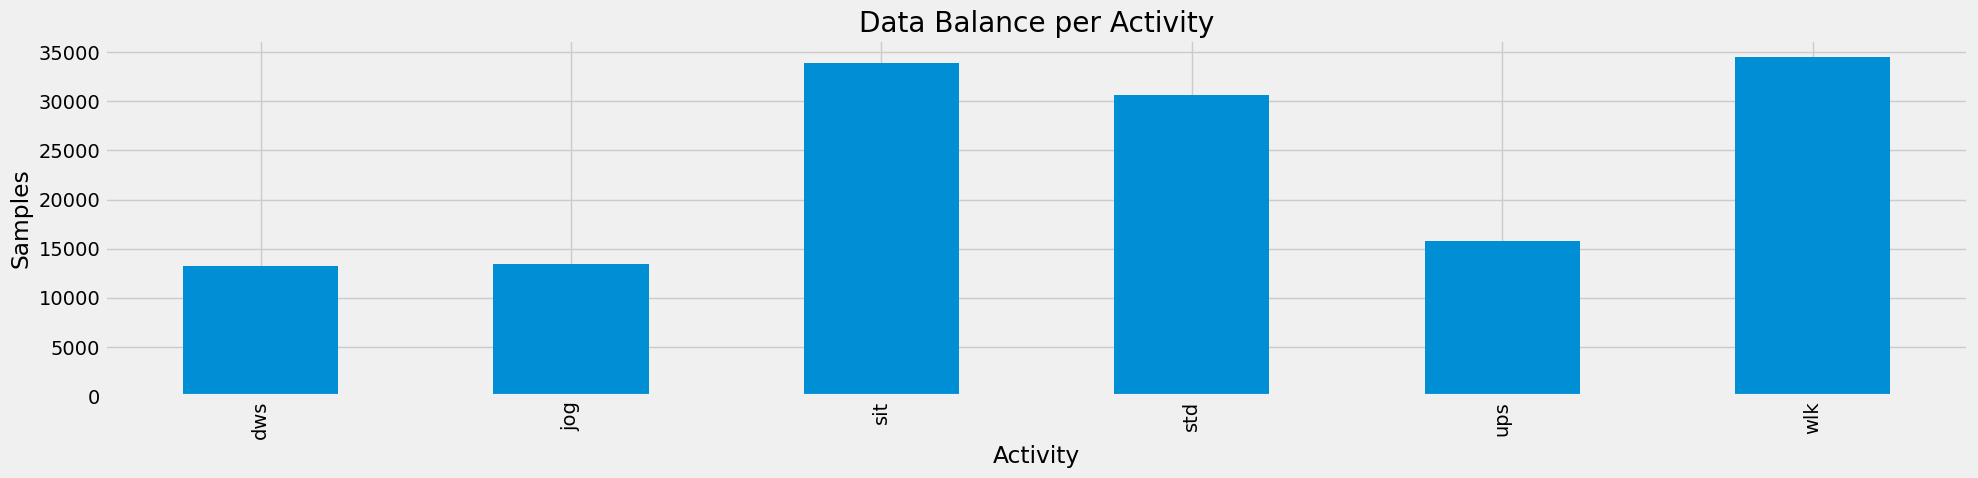

In [3]:
# 2. Data Balance

balance = df["category"].value_counts().sort_index()

plt.figure()
balance.plot(kind="bar")
plt.title("Data Balance per Activity")
plt.xlabel("Activity")
plt.ylabel("Samples")
plt.tight_layout()
plt.savefig("../../reports/figures/data_balance.png", dpi=150)
plt.show()


Mục đích 
Hiển thị tín hiệu thô của trục acceleration Y trong một set dữ liệu liên tục để kiểm tra chất lượng và hình dạng tín hiệu gốc.
=> Giúp phát hiện noise/outlier/drift sớm, hiểu pattern chu kỳ, đánh giá cần tiền xử lý gì (filter, normalize, tách gravity), và đoán sơ bộ loại hoạt động.

Pattern chu kỳ rõ rệt: Đỉnh và đáy lặp lại đều đặn (chu kỳ ≈12–15 samples), đặc trưng điển hình của hoạt động walking (mỗi bước chân tạo lực tác động lên trục Y).
Biên độ ổn định: Dao động từ ≈0.6 đến ≈1.3, biên độ mỗi chu kỳ ≈0.6–0.7, không thay đổi đột ngột → người thực hiện hoạt động đều tốc độ.
Offset dương mạnh: Giá trị trung bình ≈1.0 (gần +1g) → thành phần gravity vẫn còn, trục Y hướng gần thẳng đứng (thiết bị đeo ở hông/thắt lưng).
Tín hiệu sạch: Ít nhiễu cao tần, không có spike bất thường.

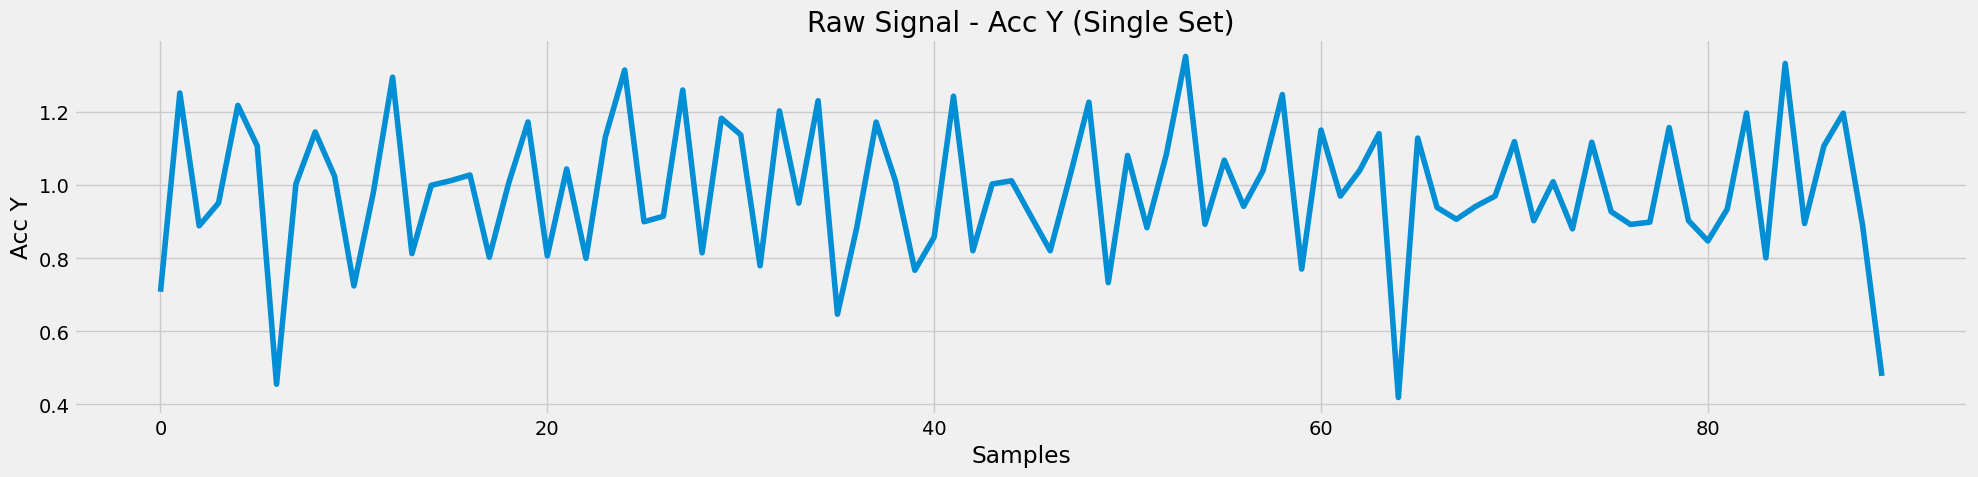

In [ ]:

# 3. Explore Single Columns

set_id = df["set"].iloc[0]
set_df = df[df["set"] == set_id]

plt.figure()
plt.plot(set_df["acc_y"].reset_index(drop=True))
plt.title("Raw Signal - Acc Y (Single Set)")
plt.xlabel("Samples")
plt.ylabel("Acc Y")
plt.tight_layout()
plt.savefig("../../reports/figures/raw_signal_acc_y.png", dpi=150)
plt.show()


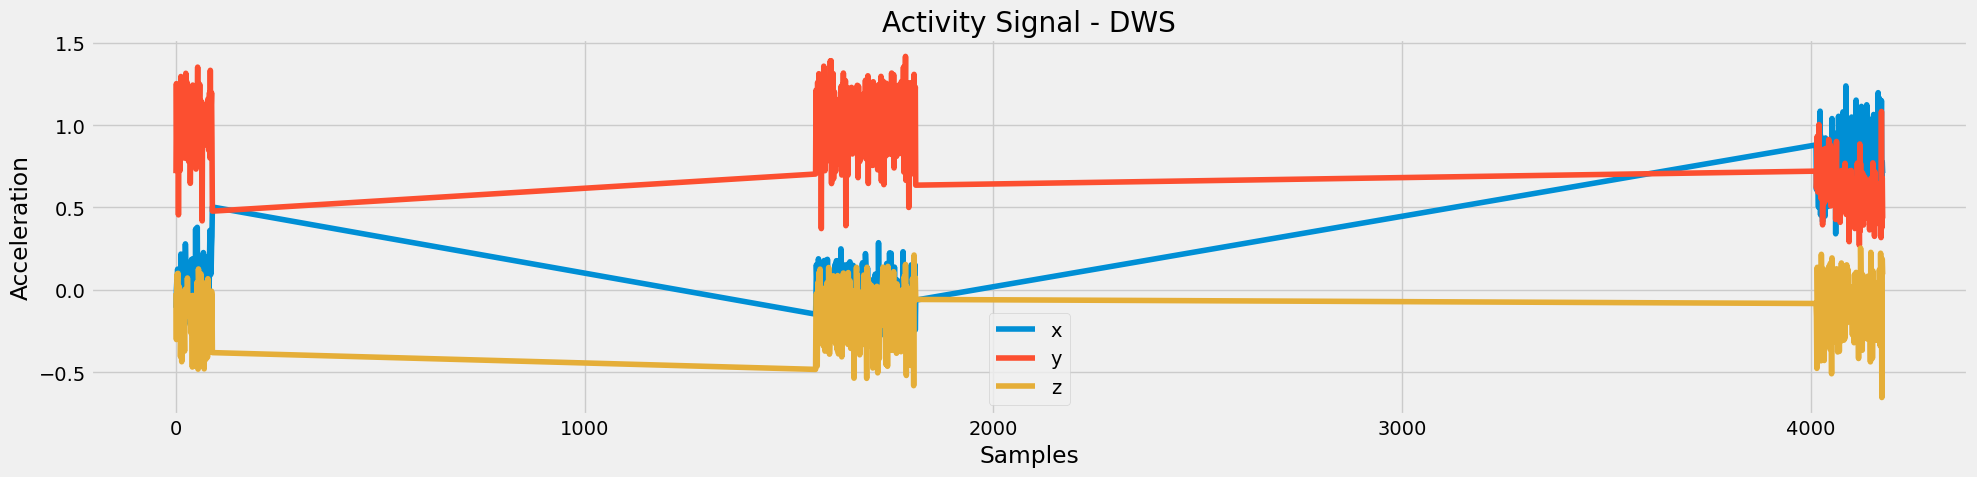

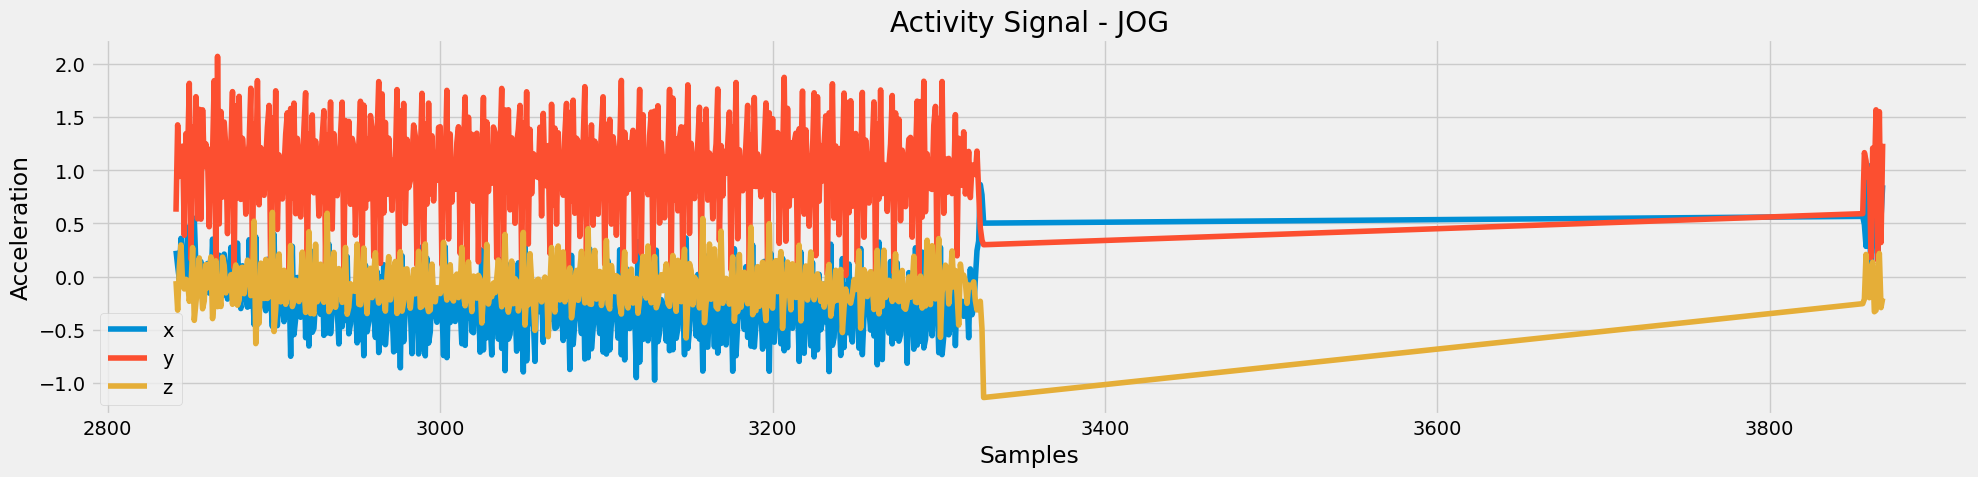

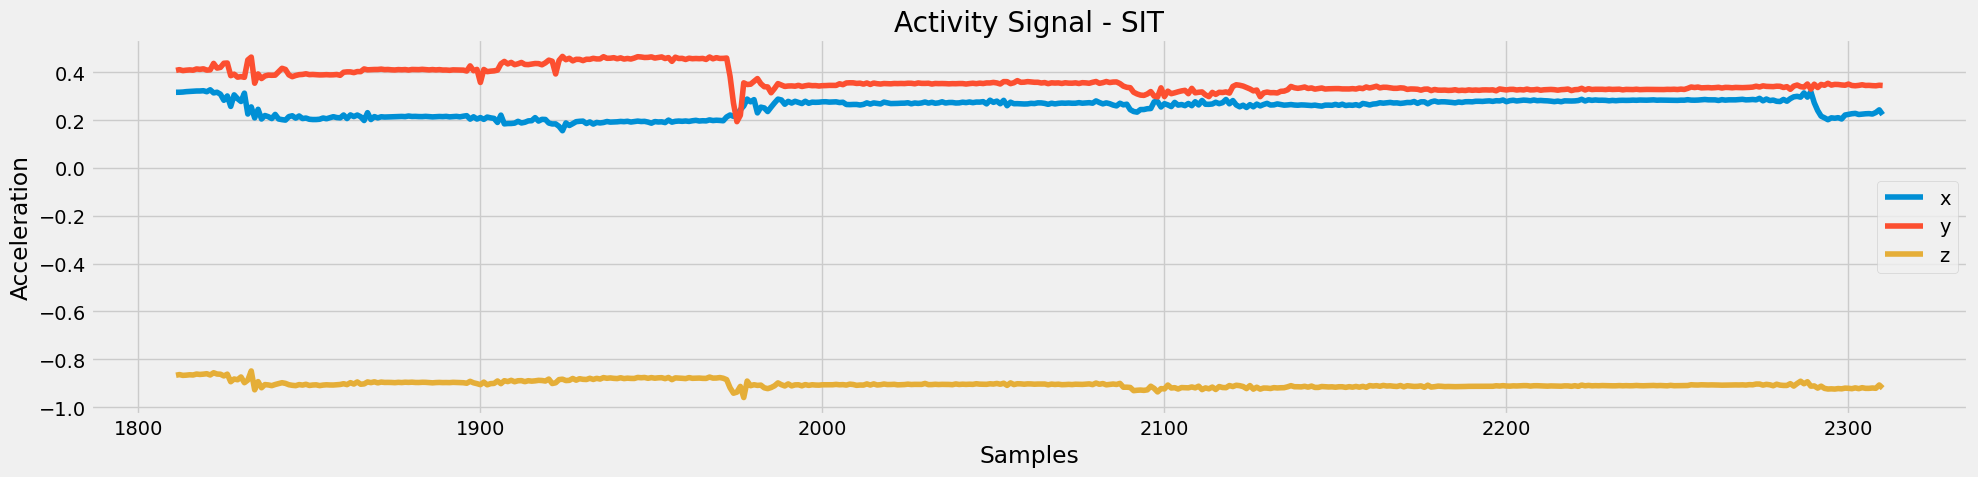

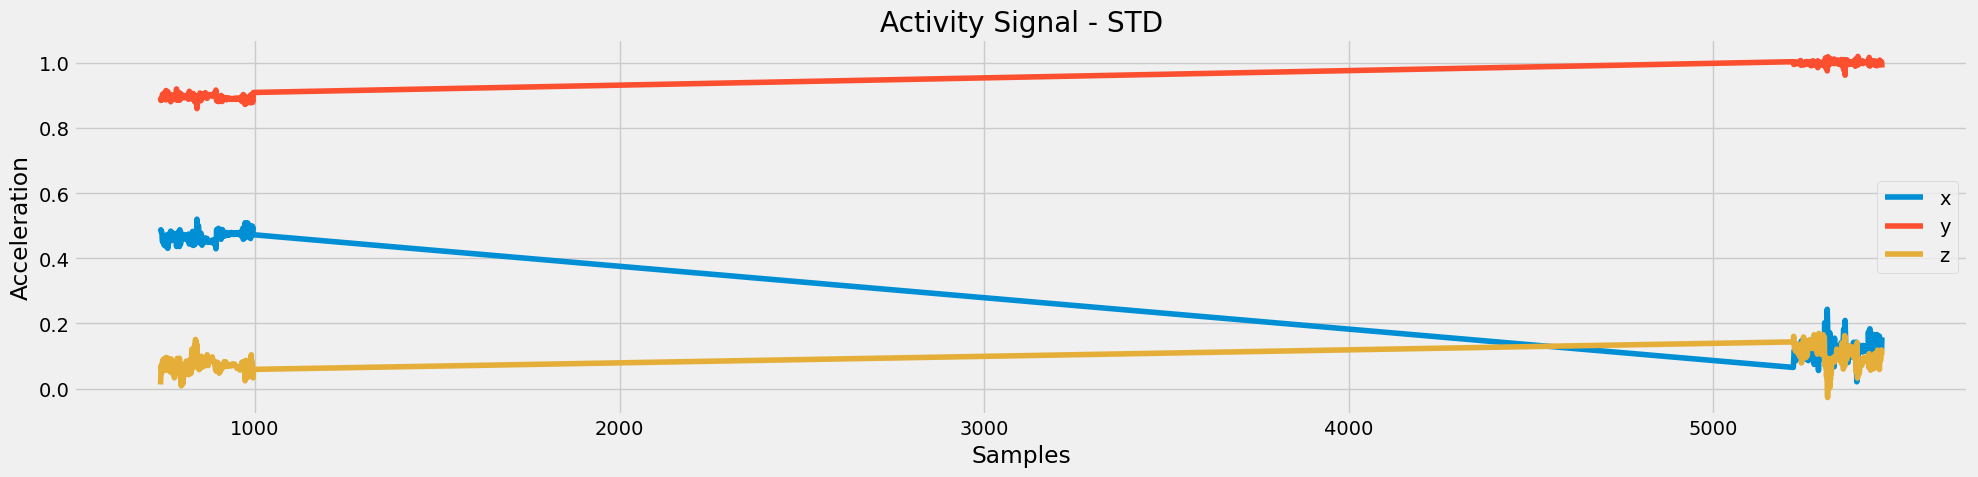

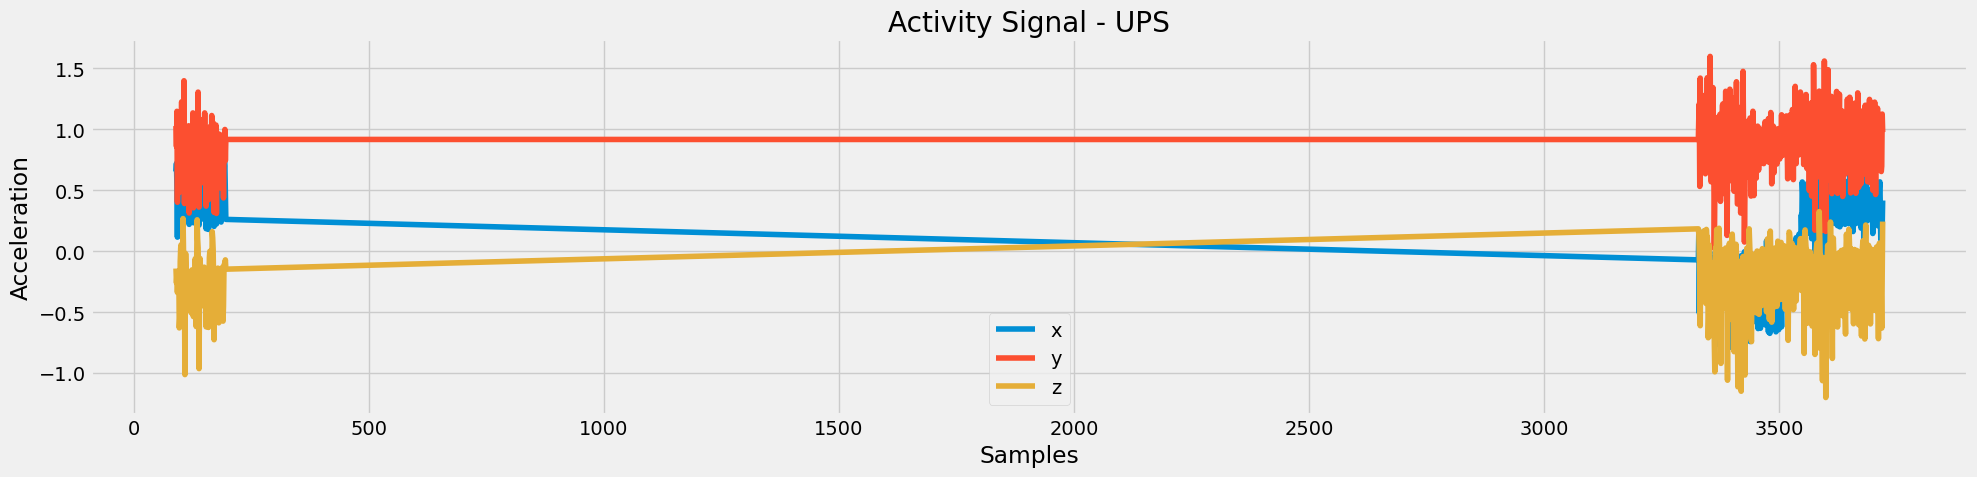

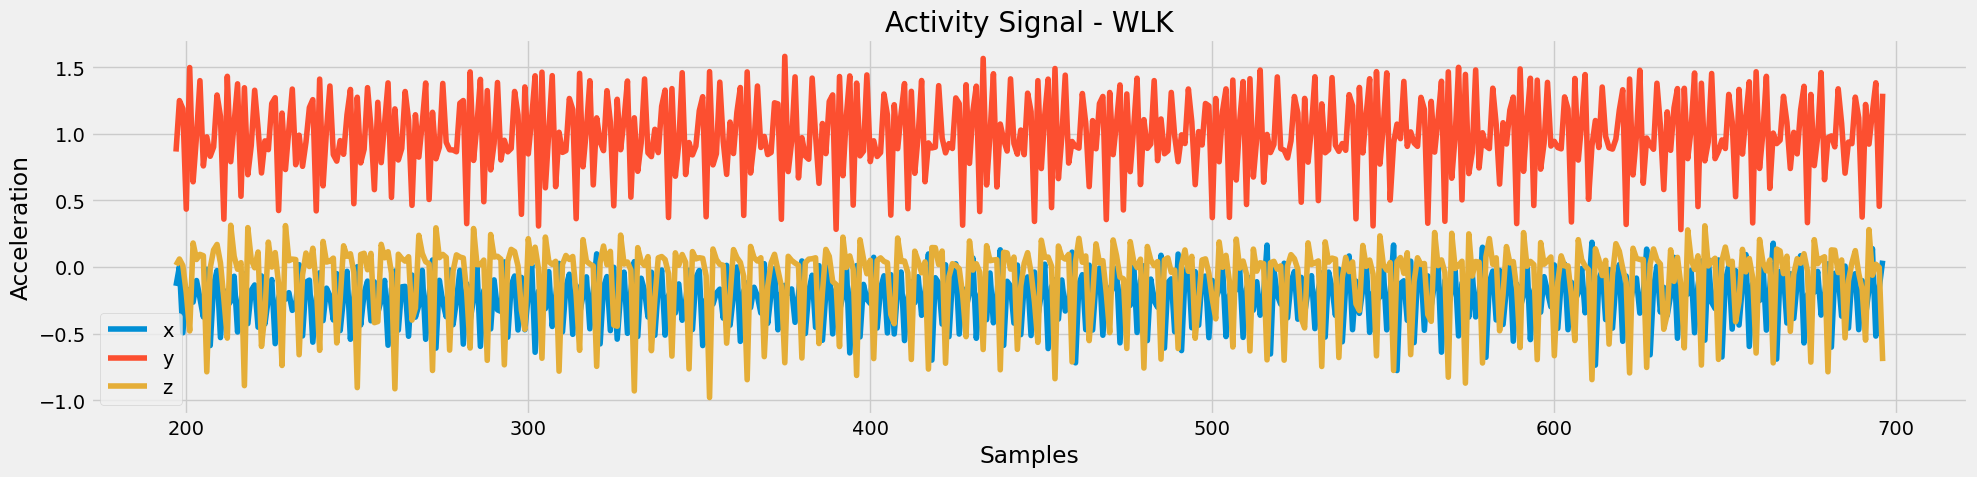

In [5]:


# 4. Plot All Activities

labels = sorted(df["category"].unique())

for label in labels:
    subset = df[df["category"] == label].head(500)

    plt.figure()
    plt.plot(subset["acc_x"], label="x")
    plt.plot(subset["acc_y"], label="y")
    plt.plot(subset["acc_z"], label="z")
    plt.title(f"Activity Signal - {label.upper()}")
    plt.xlabel("Samples")
    plt.ylabel("Acceleration")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"../../reports/figures/timeseries_{label}.png", dpi=150)
    plt.show()


In [ ]:

# 5. Compare Participants

activity = "wlk"
users = df[df["category"] == activity]["user_id"].unique()[:2]

plt.figure()
for u in users:
    u_df = df[(df["category"] == activity) & (df["user_id"] == u)].head(500)
    plt.plot(u_df["acc_y"].reset_index(drop=True), label=f"user_{u}")
s
plt.title(f"User Comparison - {activity.upper()}")
plt.xlabel("Samples")
plt.ylabel("Acc Y")
plt.legend()
plt.tight_layout()
plt.savefig(f"../../reports/figures/user_comparison_{activity}.png", dpi=150)
plt.show()

# 6. Multiple Axes Plot

label = "jog"
user = df[df["category"] == label]["user_id"].iloc[0]

multi_axis_df = (
    df.query(f"category == '{label}' and user_id == {user}")
    .head(500)
    .reset_index(drop=True)
)

plt.figure()
plt.plot(multi_axis_df["acc_x"], label="x")
plt.plot(multi_axis_df["acc_y"], label="y")
plt.plot(multi_axis_df["acc_z"], label="z")
plt.title(f"3-Axis Acceleration - {label.upper()} (User {user})")
plt.xlabel("Samples")
plt.ylabel("Acceleration")
plt.legend()
plt.tight_layout()
plt.savefig(f"../../reports/figures/3axis_{label}_user{user}.png", dpi=150)
plt.show()

# 7. Distribution and Correlation

corr_df = df[["acc_x", "acc_y", "acc_z", "gyr_x", "gyr_y", "gyr_z"]].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Sensor Correlation Heatmap")
plt.tight_layout()
plt.savefig("../../reports/figures/correlation_heatmap.png", dpi=150)
plt.show()

plt.figure()
sns.boxplot(x="category", y="acc_y", data=df)
plt.title("Acceleration Distribution per Activity")
plt.xlabel("Activity")
plt.ylabel("Acc Y")
plt.tight_layout()
plt.savefig("../../reports/figures/boxplot_acc_y.png", dpi=150)
plt.show()

# 8. Motion Shape

scatter_df = df.sample(5000, random_state=42)

plt.figure()
sns.scatterplot(
    x="acc_x",
    y="acc_y",
    hue="category",
    data=scatter_df,
    legend=False
)
plt.title("Motion Shape (Acc X vs Acc Y)")
plt.xlabel("Acc X")
plt.ylabel("Acc Y")
plt.tight_layout()
plt.savefig("../../reports/figures/scatter_motion_shape.png", dpi=150)
plt.show()

# 9. Mass Export Figures

test_users = df["user_id"].unique()[:3]

for label in labels:
    for user in test_users:
        subset = df.query(
            f"category == '{label}' and user_id == {user}"
        ).head(500)

        if subset.empty:
            continue

        fig, ax = plt.subplots(nrows=2, sharex=True, figsize=(20, 10))

        subset[["acc_x", "acc_y", "acc_z"]].plot(ax=ax[0])
        ax[0].set_title(f"{label.upper()} - User {user}")
        ax[0].set_ylabel("Acceleration")

        subset[["gyr_x", "gyr_y", "gyr_z"]].plot(ax=ax[1])
        ax[1].set_ylabel("Gyroscope")
        ax[1].set_xlabel("Samples")

        plt.tight_layout()
        plt.savefig(f"../../reports/figures/{label}_user{user}.png", dpi=150)
        plt.close(fig)